In [21]:
import numpy as np
import matplotlib.pyplot as plt


In [22]:
# create a data set
np.random.seed(42)

#genrate linear data

X1 = np.random.randn(100, 2) + np.array([-2, -2])
y1 = -np.ones(100)

In [23]:
X2 = np.random.randn(100, 2) + np.array([2, 2])
y2 = np.ones(100)

In [24]:
#combine and shuffle

X_linear = np.vstack((X1, X2))
y_linear = np.concatenate((y1, y2))
indices = np.random.permutation(len(X_liner))
X_liner = X_liner[indices]
y_linear = y_linear[indices]

In [25]:
class perceptron:
  def __init__(self, learning_rate=0.1, n_epochs=100):
    self.lr = learning_rate
    self.n_epochs = n_epochs
    self.w = np.zeros(2)
    self.b = 0.0
    self.misclassification_errors = []
    self.history = []

  def forward_pass(self, x):
    #z = w @ x + b; y_hat = sign(z)
    z = self.w @ x + self.b
    return 1 if z >=0 else -1

  def fit(self, X, Y):
    epochs_to_converge = self.n_epochs

    for epoch in range(self.n_epochs):
      errors = 0
      for xi, target in zip(X, Y):
        y_hat = self.forward_pass(xi)

        #perceptron update

        if y_hat != target:
          update = self.lr * (target - y_hat)
          self.w += update * xi
          self.b += update
          errors += 1

        # log count

        self.misclassification_errors.append(errors)
        self.history.append((self.w.copy(), self.b))

        # Early stopping

        if errors == 0 and epochs_to_converge == self.n_epochs:
          epochs_to_converge = epoch + 1
          break

    return epochs_to_converge

In [28]:
# Train on separable data
model_linear = perceptron(learning_rate=0.1, n_epochs=100)
converged_epoch = model_linear.fit(X_linear, y_linear)

# Evaluation Metrics for Separable Data
final_errors = model_linear.misclassification[-1]
accuracy = ((len(y_linear) - final_errors) / len(y_linear)) * 100

print(f"--- Linear Dataset Evaluation ---")
print(f"Training Accuracy: {accuracy}%")
print(f"Epochs to convergence: {converged_epoch}\n")

AttributeError: 'perceptron' object has no attribute 'misclassification'

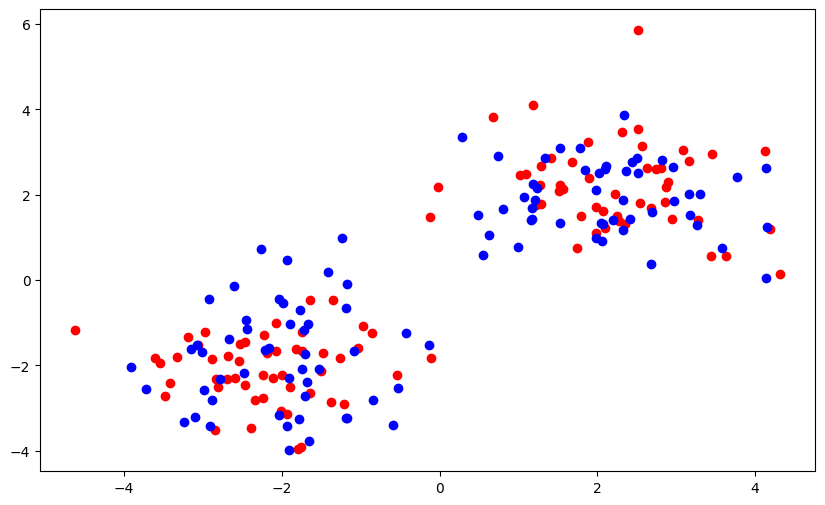

In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(X_linear[y_linear == -1][:, 0], X_linear[y_linear == -1][:, 1], color='red', label='Class -1')
plt.scatter(X_linear[y_linear == 1][:, 0], X_linear[y_linear == 1][:, 1], color='blue', label='Class 1')

x_bounds = np.array([X_linear[:, 0].min() - 1, X_linear[:, 0].max() + 1])

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


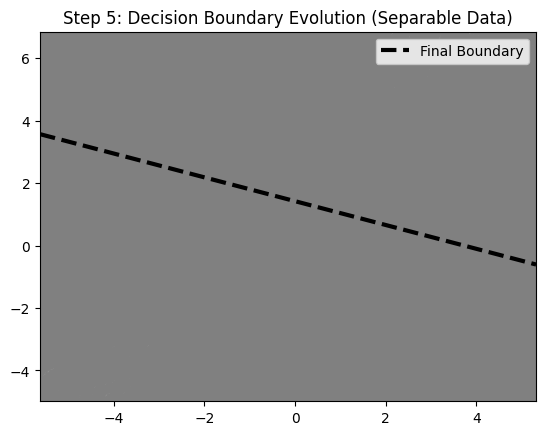

In [30]:
# Plot boundaries for each epoch in light gray
for i, (w, b) in enumerate(model_linear.history):
    if w[1] != 0: # Avoid division by zero
        y_bounds = -(w[0] * x_bounds + b) / w[1]
        plt.plot(x_bounds, y_bounds, color='gray', alpha=0.3, linewidth=1)

# Plot final decision boundary in bold black
final_w, final_b = model_linear.history[-1]
final_y_bounds = -(final_w[0] * x_bounds + final_b) / final_w[1]
plt.plot(x_bounds, final_y_bounds, color='black', linestyle='--', linewidth=3, label='Final Boundary')

plt.xlim(X_linear[:, 0].min() - 1, X_linear[:, 0].max() + 1)
plt.ylim(X_linear[:, 1].min() - 1, X_linear[:, 1].max() + 1)
plt.title("Step 5: Decision Boundary Evolution (Separable Data)")
plt.legend()
plt.show()

--- XOR Dataset Evaluation ---
Failed to converge. Misclassifications at epoch 100: 88


<function matplotlib.pyplot.show(close=None, block=None)>

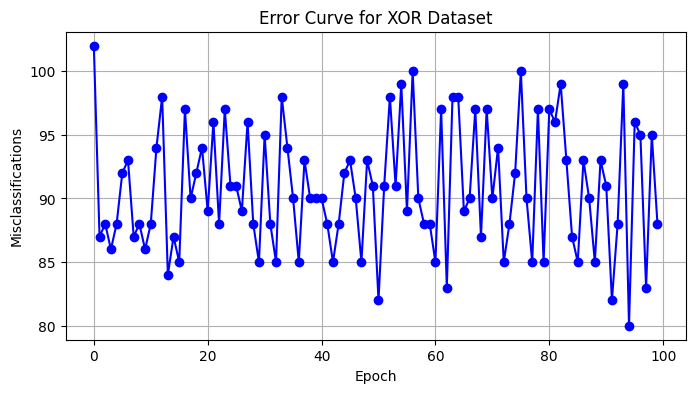

In [31]:
X_xor = np.vstack((
    np.random.randn(50, 2) * 0.5 + np.array([-2, -2]), # Bottom-left (Class -1)
    np.random.randn(50, 2) * 0.5 + np.array([2, 2]),   # Top-right (Class -1)
    np.random.randn(50, 2) * 0.5 + np.array([-2, 2]),  # Top-left (Class 1)
    np.random.randn(50, 2) * 0.5 + np.array([2, -2])   # Bottom-right (Class 1)
))
y_xor = np.concatenate((-np.ones(100), np.ones(100)))

# Shuffle
indices_xor = np.random.permutation(len(y_xor))
X_xor, y_xor = X_xor[indices_xor], y_xor[indices_xor]

# Train Perceptron on XOR data
model_xor = Perceptron(learning_rate=0.1, n_epochs=100)
model_xor.fit(X_xor, y_xor)

print(f"--- XOR Dataset Evaluation ---")
print(f"Failed to converge. Misclassifications at epoch 100: {model_xor.misclassifications[-1]}")

# Plot Error Curve for XOR to observe failure
plt.figure(figsize=(8, 4))
plt.plot(model_xor.misclassifications, marker='o', linestyle='-', color='b')
plt.title("Error Curve for XOR Dataset")
plt.xlabel("Epoch")
plt.ylabel("Misclassifications")
plt.grid(True)
plt.show